In [52]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = sns.load_dataset("iris")

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


PHẦN 1

1/ Cột 1 gồm 150 dòng và 5 cột. Trong đó, sepal_length, sepal_width, petal_length, petal_width có kiểu dữ liệu float64, còn species có kiểu dữ liệu string.

In [53]:
# 2/
cols = df.select_dtypes(include=[np.number])

summary = cols.describe()

summary.loc['mode'] = cols.mode().iloc[0]
summary.loc['var'] = cols.var()
summary.loc['IQR'] = summary.loc['75%'] - summary.loc['25%']

features = ['mean', '50%', 'mode', 'var', 'std', 'min', 'max', '25%', '75%', 'IQR']
summary.rename(index={'50': 'median', '25%': 'Q1', '75%': 'Q3'}, inplace=True)

display(summary)


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
Q1,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
Q3,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000
mode,5.000000,3.000000,1.400000,0.200000
var,0.685694,0.189979,3.116278,0.581006


In [54]:
# 3/
group = df.groupby('species').agg(['mean', 'std'])

display(group)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Nhận xét: setosa khác biệt nhất với hai loài còn lại vì petal_length và petal_width nhỏ hơn hẳn và độ lệch chuẩn của dữ liệu loài này cũng thấp.

PHẦN 2

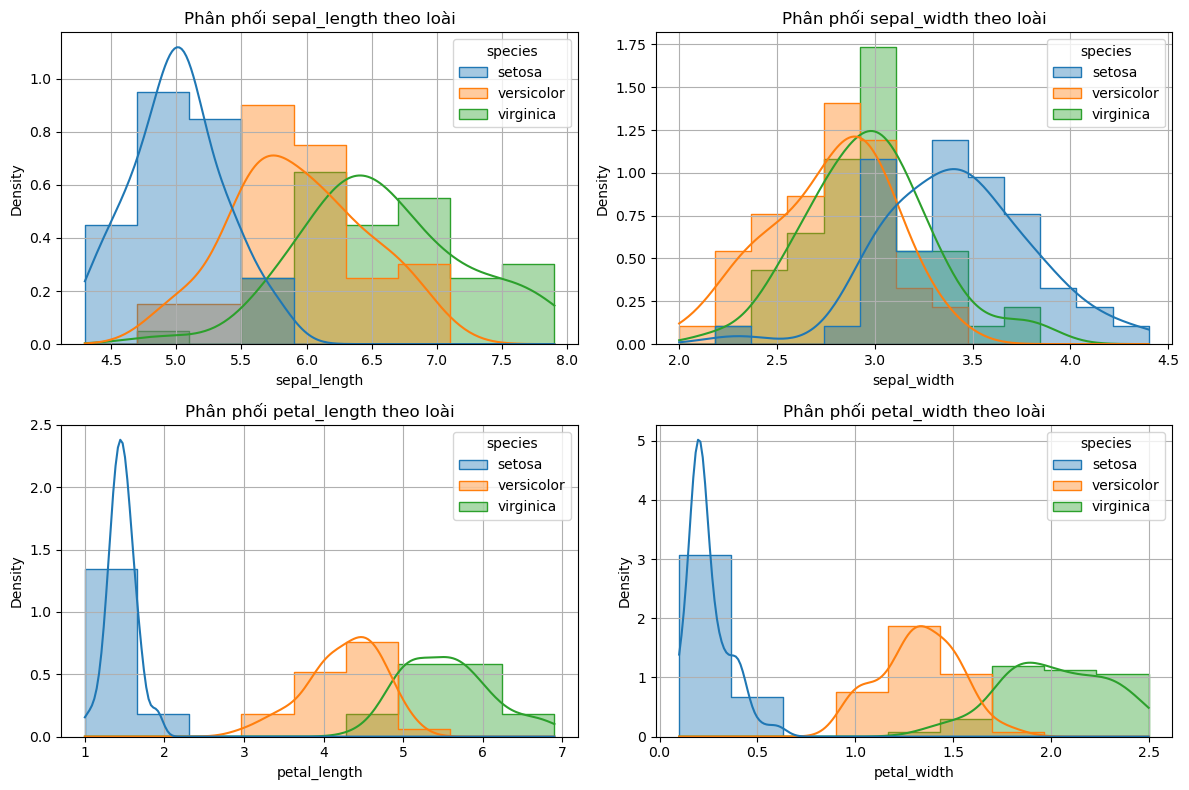

In [55]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='species', kde=True, element='step', stat='density', common_norm=False, alpha=0.4)
    plt.title(f'Phân phối {col} theo loài')
    plt.axis('on')
    plt.grid(True)
    
plt.tight_layout()
plt.show()

SEPAL_LENGTH
- Setosa: Phân phối có một đỉnh rõ ràng, có dạngchuông khá cân đối, gần phân phối chuẩn.
- Versicolor: Phân phối một đỉnh, hơi lệch phải.
- Virginica: Đường cong KDE có dạng một đỉnh lớn nhưng bề mặt histogram trải rộng và hơi gợn nhẹ ở đuôi bên phải, hình dạng lệch trái khá nhiều.

SEPAL_WIDTH
- Setosa: Phân phối một đỉnh rõ ràng, dạng hình chuông đối xứng, rất gần phân phối chuẩn.
- Versicolor: Đường cong một đỉnh nhọn, phân phối đối xứng và gần phân phối chuẩn.
- Virginica: Phân phối một đỉnh nhọn, tập trung rất cao ở chung quanh 3.0, đối xứng tốt và gần phân phối chuẩn.

PETAL_LENGTH
- Setosa: Phân phối một đỉnh cực kỳ nhọn và dốc đứng, dữ liệu có range hẹp. Phân phối lệch phải rõ rệt do có phần đuôi kéo dài về phía bên phải.
- Versicolor: Phân phối một đỉnh khá tròn, khá đối xứng, gần phân phối chuẩn.
- Virginica: Đường cong KDE có xu hướng phẳng ở đỉnh hoặc hơi tạo thành hai đỉnh nhỏ lướt qua nhau trong khoảng từ 5.0 đến 6.5, biến động không đồng đều.

PETAL_WIDTH 
- Setosa: Có một đỉnh chính rất cao ở khoảng dưới 0.4, sau đó giảm đột ngột và có một gờ nhẹ ở khoảng 0.5 - 0.6, lệch phải nặng.
- Versicolor: Phân phối một đỉnh rõ ràng, hơi nghiêng về phía bên trái .
- Virginica: Đường cong KDE trải phẳng ở đỉnh và hơi chĩa dần về hai bên, phân phối một đỉnh rộng, khá đối xứng.

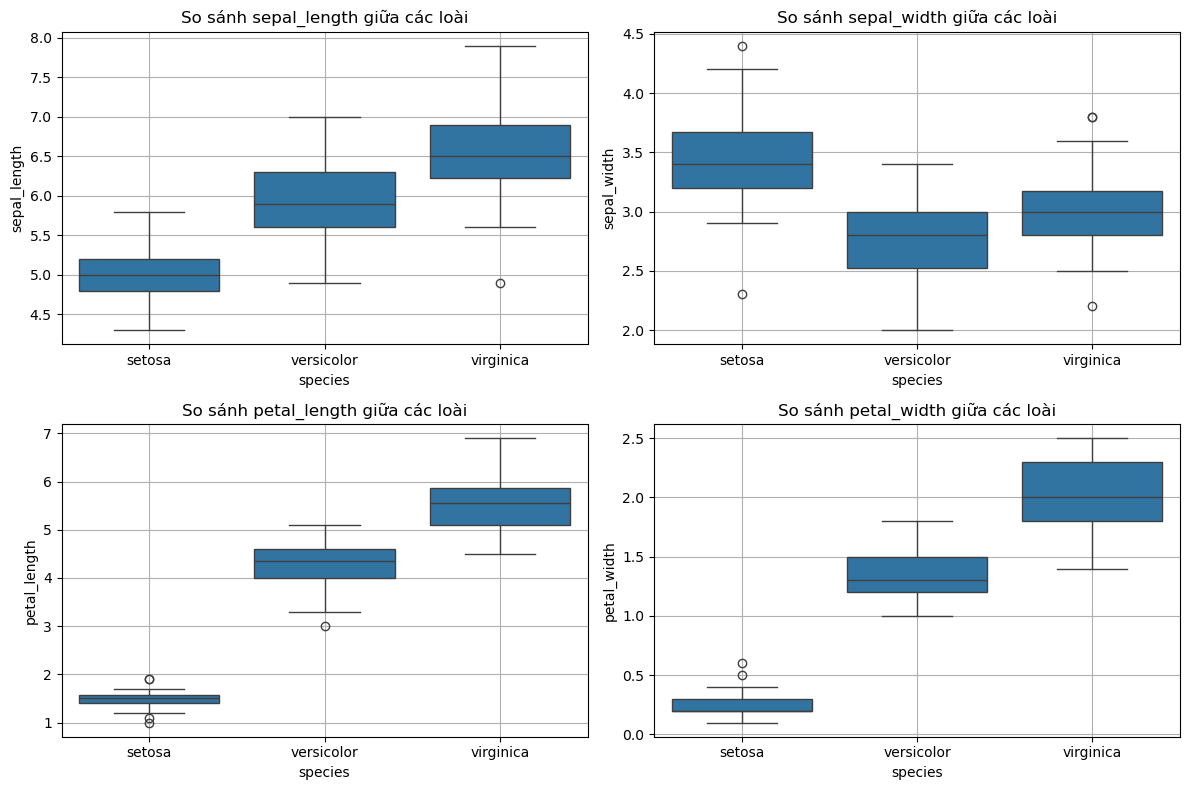

In [56]:
# 2/
plt.figure(figsize=(12, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='species', y=col, data=df)
    plt.title(f'So sánh {col} giữa các loài')
    plt.axis('on')
    plt.grid(True)

plt.tight_layout()
plt.show()

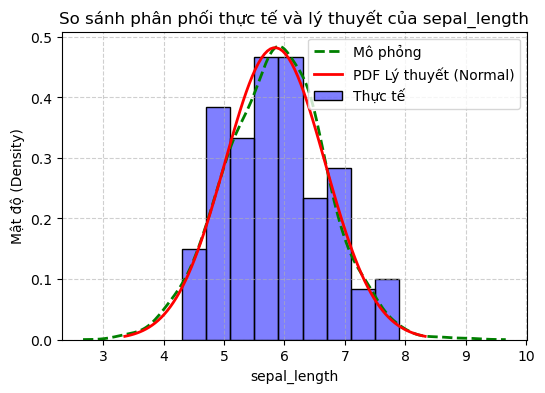

In [57]:
# 3/
chosen = 'sepal_length'

boolean_condition = df[chosen] > 0  

mu = df[chosen].mean()
sigma = df[chosen].std()

gen = np.random.normal(loc=mu, scale=sigma, size = 999)

plt.figure(figsize=(6, 4))
sns.histplot(df[chosen], stat='density', alpha=0.5, label='Thực tế', color='blue')
sns.kdeplot(gen, color='green', linestyle='--', linewidth=2, label='Mô phỏng')

x_axis = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x_axis, stats.norm.pdf(x_axis, mu, sigma), color='red', linewidth=2, label='PDF Lý thuyết (Normal)')

plt.title(f'So sánh phân phối thực tế và lý thuyết của {chosen}')
plt.xlabel(chosen)
plt.ylabel('Mật độ (Density)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() 

Nhận xét: Đường PDF lý thuyết bám khá sát phân phối histogram thực tế của sepal_length, có phân phối chuẩn tốt.

PHẦN 3

Correlation Matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


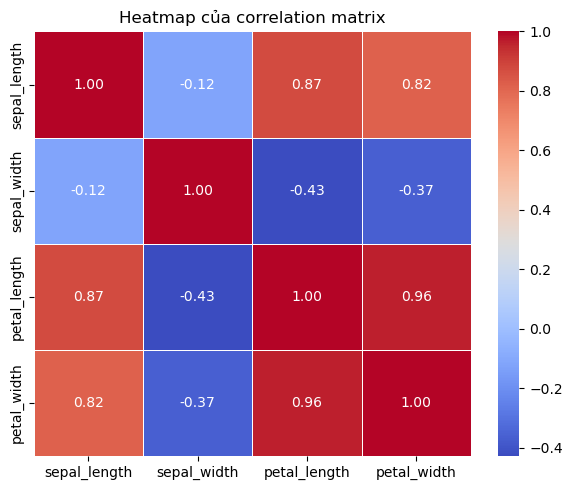

In [58]:
# 1/
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

cov_matrix = df[cols].cov()
corr_matrix = df[cols].corr()

print("Correlation Matrix")
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidth=0.5)

plt.title("Heatmap của correlation matrix")
plt.tight_layout()
plt.show()

Cặp

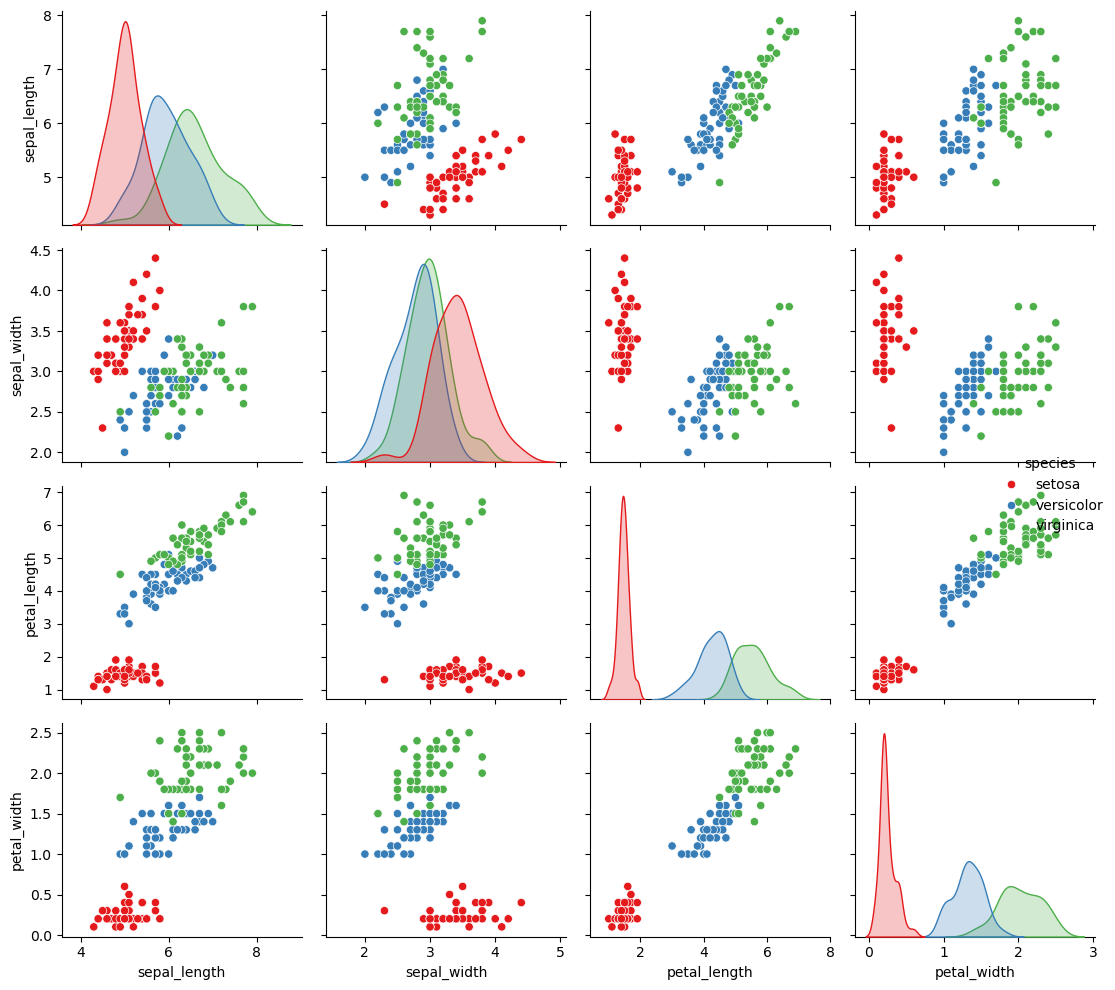

In [59]:
# 3/
sns.pairplot(df, hue='species', diag_kind='kde', palette='Set1')
plt.tight_layout()
plt.show();

PHẦN 4

Xác suất một người thực sự mắc bệnh khi có kết quả dương tính: 0.1667


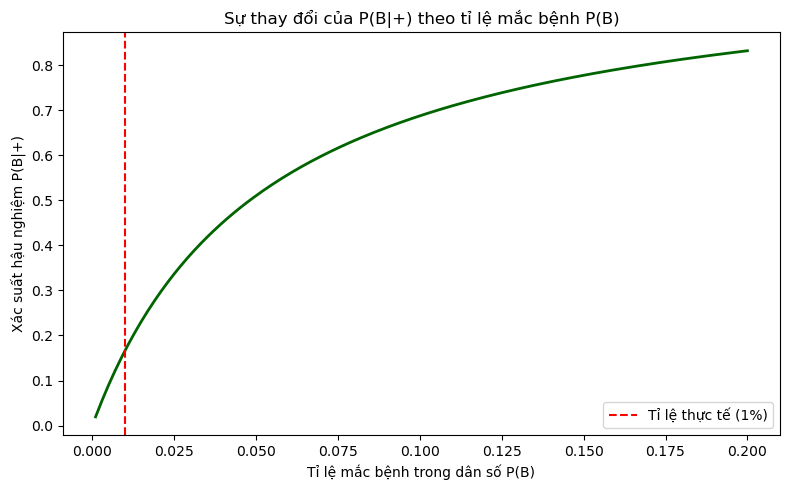

In [60]:
# 1/
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos = (P_pos_givenB * P_B) + (P_pos_givenNB * (1 - P_B))
P_B_given_pos = (P_pos_givenB * P_B) / P_pos

print(f"Xác suất một người thực sự mắc bệnh khi có kết quả dương tính: {round(P_B_given_pos, 4)}")

# 2/
p_b_space = np.linspace(0.001, 0.2, 200)
p_b_given_pos_space = []

for pb in p_b_space:
    p_pos = (P_pos_givenB * pb) + (P_pos_givenNB * (1 - pb))
    pb_given_pos = (P_pos_givenB * pb) / p_pos
    p_b_given_pos_space.append(pb_given_pos)

plt.figure(figsize=(8, 5))
plt.plot(p_b_space, p_b_given_pos_space, color='darkgreen', linewidth=2)
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất hậu nghiệm P(B|+)')
plt.title('Sự thay đổi của P(B|+) theo tỉ lệ mắc bệnh P(B)')
plt.axvline(x=0.01, color='red', linestyle='--', label='Tỉ lệ thực tế (1%)')
plt.tight_layout()
plt.legend()
plt.show()

Dù xét nghiệm có đúng tới 99% nhưng nếu được chẩn đoán dương tính cũng rất thấp. vì bệnh quá hiếm trong cộng đồng P(B) = 1. Số ca dương tính giả từ 99% số người lành tính lớn hơn rất nhiều so với số ca dương tính thật từ 1% số người nhiễm bệnh. Do đó, phần lớn người nhận kết quả dương tính thực chất lại là người khỏe mạnh. Khi tỉ lệ nền P(B) tăng lên, xác suất P(B|+) mới tăng mạnh lên 